# F2 分子 VQE 教程（12-Qubit Active Space）

目标：
- 使用 WSL 端导出的 F2 12 比特哈密顿量
- 构建可调参数的 custom ansatz
- 运行 VQE 并与 FCI 参考值比较

## 1. 参数配置
F2 采用如下 active-space 规则：freeze 1a1,2a1,3a1,4a1；active 1e1,2e1,3e1,4e1,5a1,6a1（对应 12 qubits）。

In [33]:
from pathlib import Path
import json
import math

# Geometry / chemistry config
R = 2.6
R_UNIT = 'angstrom'
BASIS = 'sto-3g'
MULTIPLICITY = 1
CHARGE = 0

# VQE config
cfg = {
    'layers': 2,
    'shots': 4096,
    'max_iters': 20,
    'learning_rate': 0.1,
    'seed': 7,
    'gradient_method': 'autograd',
    'prefer_chips': 'Simulator',
    'shift': math.pi / 2,
}

print('R =', R, R_UNIT)
print('Basis =', BASIS)
print('VQE cfg =', cfg)

R = 2.6 angstrom
Basis = sto-3g
VQE cfg = {'layers': 2, 'shots': 4096, 'max_iters': 20, 'learning_rate': 0.1, 'seed': 7, 'gradient_method': 'autograd', 'prefer_chips': 'Simulator', 'shift': 1.5707963267948966}


## 2. 读取 WSL 导出的 12-qubit 哈密顿量
默认文件：`../data/f2_R2.6_angstrom_sto-3g_12q.json`

若文件不存在，请在 WSL 中执行：
```bash
cd /mnt/d/OneDrive/work/research/code/Quantum_control
python chemistry/scripts/export_f2_terms_wsl.py --R 2.6 --unit angstrom --reduction paper12 --output chemistry/data/f2_R2.6_angstrom_sto-3g_12q.json
```

In [34]:
from __future__ import annotations

import os
import json
from pathlib import Path

# Work around duplicated OpenMP runtime loading on Windows notebook kernels.
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

from quantum_hw import QuantumHardwareClient
from quantum_hw.algorithms import VQERunner

json_path = Path(f'../data/f2_R{R:.1f}_{R_UNIT}_sto-3g_12q.json')
data = json.loads(json_path.read_text(encoding='utf-8'))

f2_constant = float(data['constant'])
f2_12q_terms = [(float(c), str(obs)) for c, obs in data['terms']]
nqubits = int(data['nqubits'])
fci_energy = float(data['fci_energy'])

print('Loaded from:', json_path)
print('nqubits:', nqubits)
print('term_count:', len(f2_12q_terms))
print('fci_energy:', fci_energy)

Loaded from: ..\data\f2_R2.6_angstrom_sto-3g_12q.json
nqubits: 12
term_count: 382
fci_energy: -195.9734686096283


## 3. 构建 F2 12-qubit Custom Ansatz
F2共18个电子，冻结最低4个轨道后还剩10个电子和6个轨道，因此HF态是|111111111100>
结合对称性限制和激发能量，只考虑UCC中的最关键项，包括

$$
a_{11}^\dagger a_{10}^\dagger a_1 a_0, \quad a_{11}^\dagger a_{10}^\dagger a_3 a_2, \quad a_{11}^\dagger a_{10}^\dagger a_5 a_4, \quad a_{11}^\dagger a_{10}^\dagger a_7 a_6, \quad a_{11}^\dagger a_{10}^\dagger a_9 a_8
$$

对应的UCC为

$$
U(\theta) =
\exp\left[-i\theta_5 Y_8 Y_9 Y_{10} X_{11} -i\theta_4 Y_6 Y_7 Y_{10} X_{11} - i\theta_3 Y_4 Y_5 Y_{10} X_{11} - i\theta_2 Y_2 Y_3 Y_{10} X_{11} - i\theta_1 Y_0 Y_1 Y_{10} X_{11}
\right]
$$


In [51]:
from quantum_hw.circuit import QuantumCircuit
def build_f2_symbolic_ansatz() -> QuantumCircuit:
    qc = QuantumCircuit(12)

    # HF state or "singlet" reference state
    qc.ry("theta_0", 8)
    qc.cx(8, 9)
    qc.cx(9, 10)
    qc.cx(10, 11)

    for q in range(10):
        qc.x(q)

    qc.pauli_evolution("theta_1", "Y0 Y1 Y10 X11")
    qc.pauli_evolution("theta_2", "Y2 Y3 Y10 X11")
    qc.pauli_evolution("theta_3", "Y4 Y5 Y10 X11")
    qc.pauli_evolution("theta_4", "Y6 Y7 Y10 X11")
    qc.pauli_evolution("theta_5", "Y8 Y9 Y10 X11")

    return qc
custom_ansatz_qc = build_f2_symbolic_ansatz()

from quantum_hw.api import Backend
backend = Backend("Simulator")
client = QuantumHardwareClient()
transpiled_circuit = client._transpile_with_backend(custom_ansatz_qc, backend, use_gate_compressor=False,use_dd=False,target_qubits=list(range(nqubits)))
transpiled_circuit = transpiled_circuit.mapping_to_others(transpiled_circuit.physical_to_logical)
symbolic_params = sorted(
    [k for k, v in custom_ansatz_qc.params_value.items() if isinstance(k, str) and isinstance(v, str)]
)
print('Total gates in custom F2 ansatz:', len(transpiled_circuit.gates))
print('Parameter count:', len(symbolic_params))

Total gates in custom F2 ansatz: 653
Parameter count: 6


## 4. 运行 VQE（模拟器）

[vqe] prepare run: name=f2_12q_custom num_qubits=12 model=custom layers=1 shots=4096 max_iters=20
[vqe] candidate chips: ['Simulator']
[vqe] running on chip: Simulator
[vqe] start optimization: iters=20 layers=1 params=6 ansatz=custom shots=4096 shift=1.5707963267948966 gradient=autograd
[vqe] iter 0 start
[vqe] iter 0 energy=-5.625485 grad_norm=0.556542
[vqe] iter 0 new best energy=-5.625485
[vqe] iter 1 start
[vqe] iter 1 energy=-5.704922 grad_norm=0.514295
[vqe] iter 1 new best energy=-5.704922
[vqe] iter 2 start
[vqe] iter 2 energy=-5.770702 grad_norm=0.459590
[vqe] iter 2 new best energy=-5.770702
[vqe] iter 3 start
[vqe] iter 3 energy=-5.837759 grad_norm=0.417025
[vqe] iter 3 new best energy=-5.837759
[vqe] iter 4 start
[vqe] iter 4 energy=-5.898109 grad_norm=0.361058
[vqe] iter 4 new best energy=-5.898109
[vqe] iter 5 start
[vqe] iter 5 energy=-5.940007 grad_norm=0.289281
[vqe] iter 5 new best energy=-5.940007
[vqe] iter 6 start
[vqe] iter 6 energy=-5.967125 grad_norm=0.219626
[

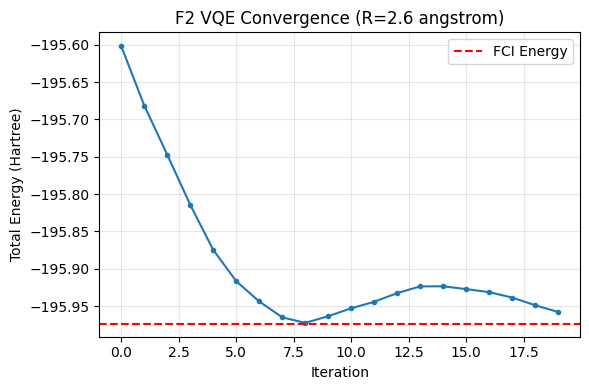

In [52]:
runner = VQERunner(
    client=QuantumHardwareClient(),
    shots=cfg['shots'],
    max_iters=cfg['max_iters'],
    learning_rate=cfg['learning_rate'],
    gradient_method=cfg['gradient_method'],
    seed=cfg['seed'],
    shift=cfg['shift'],
)

kwargs = {
    'name': 'f2_12q_custom',
    'num_qubits': nqubits,
    'model': 'custom',
    'hamiltonian': f2_12q_terms,
    'ansatz': 'custom',
    'custom_ansatz_circuit': transpiled_circuit,
    'prefer_chips': cfg['prefer_chips'],
    'init_params': [0.01] * len(symbolic_params),
}

res = runner.run_model(**kwargs)
e_total = f2_constant + res.best_energy
abs_error_fci = abs(e_total - fci_energy)
print('=== 12-Qubit F2 VQE Result ===')
print('Estimated total energy:  ', round(e_total, 8))
print('FCI reference energy:    ', round(fci_energy, 8))
print('Absolute error vs FCI:   ', round(abs_error_fci, 8))

import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(6, 4))
plt.plot(np.array(res.energy_history) + f2_constant, marker='o', ms=3)
plt.axhline(fci_energy, color='red', linestyle='--', label='FCI Energy')
plt.legend()
plt.xlabel('Iteration')
plt.ylabel('Total Energy (Hartree)')
plt.title(f'F2 VQE Convergence (R={R} {R_UNIT})')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. 计算完整的能量曲线
按不同键长 R 扫描 F2 的势能面，并与每个 R 对应的 FCI 参考值比较。

In [53]:
import numpy as np

R_scan = np.arange(1.0, 3.01, 0.3)
energy_ucc = []
cfg['gradient_method'] = 'autograd'
# Keep scan on simulator to avoid accidental hardware submissions.
scan_cfg = {
    'layers': cfg['layers'],
    'shots': cfg['shots'],
    'max_iters': cfg['max_iters'],
    'learning_rate': cfg['learning_rate'],
    'gradient_method': cfg['gradient_method'],
    'seed': cfg['seed'],
    'shift': cfg['shift'],
    'prefer_chips': 'Simulator',
}

for R_now in R_scan:
    json_path = Path(f'../data/f2_R{R_now:.1f}_angstrom_sto-3g_12q.json')
    data = json.loads(json_path.read_text(encoding='utf-8'))

    f2_constant_now = float(data['constant'])
    f2_terms_now = [(float(c), str(obs)) for c, obs in data['terms']]
    nqubits_now = int(data['nqubits'])
    fci_energy_now = float(data['fci_energy'])

    runner_scan = VQERunner(
        client=QuantumHardwareClient(),
        layers=scan_cfg['layers'],
        shots=scan_cfg['shots'],
        max_iters=scan_cfg['max_iters'],
        learning_rate=scan_cfg['learning_rate'],
        gradient_method=scan_cfg['gradient_method'],
        seed=scan_cfg['seed'],
        shift=scan_cfg['shift'],
    )

    kwargs_scan = {
        'name': f'f2_12q_custom_R{R_now:.1f}',
        'num_qubits': nqubits_now,
        'model': 'custom',
        'hamiltonian': f2_terms_now,
        'ansatz': 'custom',
        'custom_ansatz_circuit': transpiled_circuit,
        'prefer_chips': scan_cfg['prefer_chips'],
        'init_params': [0.0] * len(symbolic_params),
    }

    res_scan = runner_scan.run_model(**kwargs_scan)
    e_total_now = f2_constant_now + res_scan.best_energy

    energy_ucc.append({
        'R': R_now,
        'e_total': e_total_now,
        'fci': fci_energy_now,
    })

print('scan points =', len(energy_ucc))
print('first point =', energy_ucc[0] if energy_ucc else None)
print('last point  =', energy_ucc[-1] if energy_ucc else None)

[vqe] prepare run: name=f2_12q_custom_R1.0 num_qubits=12 model=custom layers=2 shots=4096 max_iters=20
[vqe] candidate chips: ['Simulator']
[vqe] running on chip: Simulator
[vqe] start optimization: iters=20 layers=2 params=6 ansatz=custom shots=4096 shift=1.5707963267948966 gradient=autograd
[vqe] iter 0 start
[vqe] iter 0 energy=-8.167167 grad_norm=0.196162
[vqe] iter 0 new best energy=-8.167167
[vqe] iter 1 start
[vqe] iter 1 energy=-8.162304 grad_norm=0.244734
[vqe] iter 2 start
[vqe] iter 2 energy=-8.176564 grad_norm=0.123307
[vqe] iter 2 new best energy=-8.176564
[vqe] iter 3 start
[vqe] iter 3 energy=-8.175304 grad_norm=0.129656
[vqe] iter 4 start
[vqe] iter 4 energy=-8.168422 grad_norm=0.195177
[vqe] iter 5 start
[vqe] iter 5 energy=-8.172812 grad_norm=0.160216
[vqe] iter 6 start
[vqe] iter 6 energy=-8.180166 grad_norm=0.065046
[vqe] iter 6 new best energy=-8.180166
[vqe] iter 7 start
[vqe] iter 7 energy=-8.180892 grad_norm=0.046353
[vqe] iter 7 new best energy=-8.180892
[vqe] 

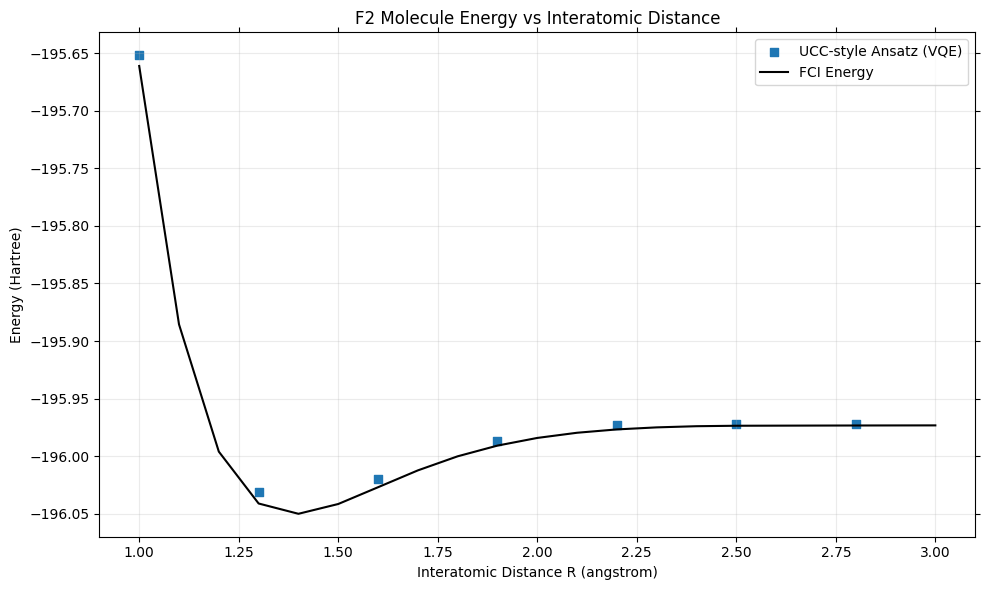

In [54]:
from matplotlib import pyplot as plt

R_range = np.arange(1, 3.01, 0.1)
fci_energies = []
for R in R_range:
    json_path = Path(f'../data/f2_R{R:.1f}_angstrom_sto-3g_12q.json')
    data = json.loads(json_path.read_text(encoding='utf-8'))
    fci_energies.append(float(data['fci_energy']))
R_values = [item['R'] for item in energy_ucc]
estimated_energies_ucc = [item['e_total'] for item in energy_ucc]

plt.figure(figsize=(10, 6))
plt.scatter(R_values, estimated_energies_ucc, marker='s', label='UCC-style Ansatz (VQE)')
plt.plot(R_range, fci_energies, 'k-', label='FCI Energy')
plt.xlabel('Interatomic Distance R (angstrom)')
plt.ylabel('Energy (Hartree)')
plt.title('F2 Molecule Energy vs Interatomic Distance')
plt.legend()
plt.tick_params(right=True, top=True)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()